# OKcupid dataset
In this assignment, you will analyze data on OKcupid dating profiles.

Import the relevant packages:

In [96]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

Import the dataset:

In [97]:
profiles = pd.read_csv('profiles_revised.csv')
essays = pd.read_csv('essays_revised_and_shuffled.csv')

print("profile shape =" + str(profiles.shape))
print("essays shape =" + str(essays.shape))


profile shape =(59946, 19)
essays shape =(59946, 10)


lets see what do we have:

In [98]:
profiles.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,36,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,37,thin,anything,socially,NaN,graduated from masters program,NaN,68.0,-1,NaN,NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,22,thin,vegetarian,socially,NaN,working on college/university,white,71.0,20000,student,doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,30,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [99]:
essays.head()

,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,"well hi there. my mantra this year is ""<a clas...","working, exploring the world, and meeting cool...","playing the <a class=""ilink"" href=""/interests?...",my laugh (if i happen to be laughing (or playi...,"way too many of each to count, so i'll just wr...",a piano<br />\nbig picture windows with panora...,adventures that i've yet to have,"probably working late, then coming home to cra...",i named my roomba. philippe and i have had som...,-you believe that community is a gift from the...
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,musician / writer / programmer from the woods ...,"working for startups, destroying dancefloors, ...",taking things apart and fixing them. cooking w...,NaN,my music collection is a little bit out of con...,"lowpass filters, spanish rice, public radio, w...",cosmology and the fate of the universe.,"""you can find me in the club"" - curtis james j...",i've been skating for 6 years and only learned...,"you need some money moved out of nigeria, or i..."
3,nothing in this world can take the place of pe...,i'm committed full-time to my art practice. i ...,painting. observational comedy. finding cool s...,"i'm tall. i don't know, you tell me...","artists- anselm kiefer, peter doig, edvard mun...",-art<br />\n<br />\n-tunes<br />\n<br />\n-npr...,-how i can keep evolving as an artist and pers...,either locked in the studio or out on the town!,i think terry gross' snort when she laughs is ...,"i'm looking to find a good, kind-hearted woman..."
4,"i'm a sweet, sassy, easy going, low femme look...",i'm a public interest lawyer. i am passionate ...,creative cooking projects<br />\nhosting parti...,my curly hair and hopefully my sparkle.,a few favorites: movies + tv = woody allen; fe...,"i could never do without love and community, a...",time with friends somewhere gorgeous and woods...,looking for love in all the wrong places.,sometimes i tend toward hyperbole.,you think i might be interesting and/or cute o...


looks like there are alot of NANs

<Axes: >

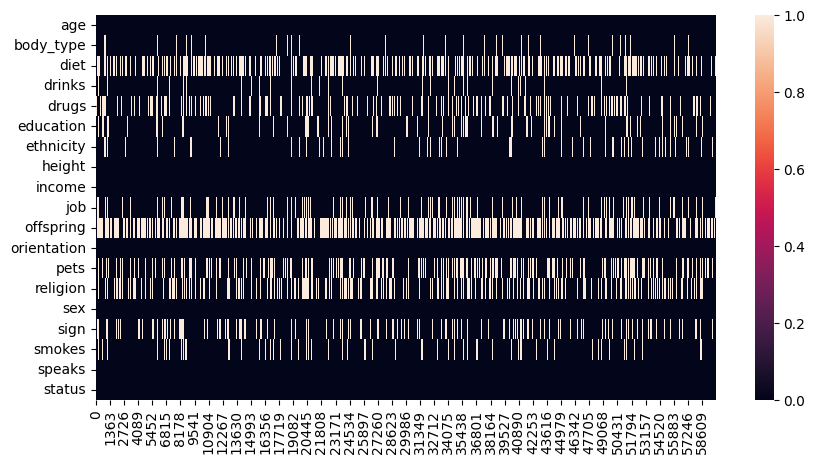

In [100]:
sns.heatmap(profiles.isnull().T.astype(int))

we can assume that anyone that has NAN in offspring just didnt bother to say didnt have one and assign the "doesn't have kids , doesn't know if want kids in the future".

For religion NANs the default should be the "agnosticism but not too serious about it".

non-smokers will not bother to write they do not smoke so every NAN there should be a "no".

same for the drugs category they will not bother to write they do not use drugs so every NAN there should be a "never".

i think that NANs in the sign category should say the "it doesn't matter"

in the diet category we can do imputaion of the most common value.

in the body type category we can do imputaion of the most common value too.

in the drinks category we can do imputaion of the most common value too.

in the ethnicity category we can do imputaion of the most common value too.

in the job category we can do imputaion with the "rather not say" value.

in the pets category each NAN should be a "have no opinion on pets". 



with the essays we could treat them as a "soup of words" and find statistics on keywords and word combinations.






Clean the profiles dataset:

<Axes: >

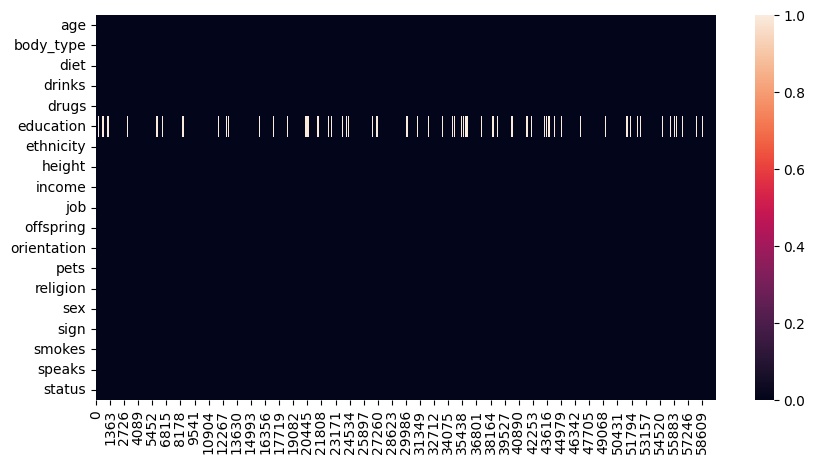

In [101]:


# --- offspring ---
# Anyone with NaN didn't bother stating they have kids → assume no kids, unsure about the future
profiles['offspring'] = profiles['offspring'].fillna("doesn't have kids, doesn't know if want kids in the future")

# --- religion ---
# Default NaN → agnosticism but not too serious about it
profiles['religion'] = profiles['religion'].fillna('agnosticism but not too serious about it')

# --- smokes ---
# Non-smokers won't bother writing they don't smoke → fill with "no"
profiles['smokes'] = profiles['smokes'].fillna('no')

# --- drugs ---
# Non-users won't bother writing they never use drugs → fill with "never"
profiles['drugs'] = profiles['drugs'].fillna('never')

# --- sign ---
# Fill with "it doesn't matter" as the neutral / unspecified category
profiles['sign'] = profiles['sign'].fillna("it doesn't matter")

# --- diet ---
# Impute with the most common value (mode)
profiles['diet'] = profiles['diet'].fillna(profiles['diet'].mode()[0])

# --- body_type ---
# Impute with the most common value (mode)
profiles['body_type'] = profiles['body_type'].fillna(profiles['body_type'].mode()[0])

# --- drinks ---
# Impute with the most common value (mode)
profiles['drinks'] = profiles['drinks'].fillna(profiles['drinks'].mode()[0])

# --- ethnicity ---
# Impute with the most common value (mode)
profiles['ethnicity'] = profiles['ethnicity'].fillna(profiles['ethnicity'].mode()[0])

# --- job ---
# Fill with "rather not say" as a neutral / privacy-respecting category
profiles['job'] = profiles['job'].fillna('rather not say')

# --- pets ---
# Fill with "have no opinion on pets" for those who didn't answer
profiles['pets'] = profiles['pets'].fillna('have no opinion on pets')


sns.heatmap(profiles.isnull().T.astype(int))

i think the education category can be imputed based on KNN. i am doing it before the encoding which maybe not the best way but good enough.

In [102]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# --- education (KNN imputation) ---
# Use already-cleaned categorical + numerical features to find K nearest
# neighbours and impute the missing education level via majority vote.

# Record which rows are missing education (before any encoding)
edu_missing = profiles['education'].isna()

# Categorical features to use as KNN predictors (all fully cleaned above)
knn_cat_cols = ['sex', 'orientation', 'status', 'drinks', 'drugs',
                 'smokes', 'body_type', 'diet', 'job']
# Numerical features (height has 3 NaNs — KNNImputer handles them automatically)
knn_num_cols = ['age', 'height', 'income']

# Build working copy
edu_df = profiles[knn_cat_cols + knn_num_cols + ['education']].copy()

# Label-encode the categorical predictor columns (no NaNs at this point)
label_encoders = {}
for col in knn_cat_cols:
    le = LabelEncoder()
    edu_df[col] = le.fit_transform(edu_df[col])
    label_encoders[col] = le

# Label-encode education — fit only on the known values, keep NaN as NaN
edu_le = LabelEncoder()
edu_le.fit(edu_df['education'].dropna())
known = edu_df['education'].notna()
edu_df.loc[known, 'education']  = edu_le.transform(edu_df.loc[known, 'education']).astype(float)
edu_df.loc[~known, 'education'] = float('nan')

# Run KNN imputer (k=5) — fills NaNs in education (and the 3 height NaNs)
imputer = KNNImputer(n_neighbors=5)
imputed_arr = imputer.fit_transform(edu_df)
imputed_df  = pd.DataFrame(imputed_arr, columns=edu_df.columns, index=profiles.index)

# Round the imputed education index to nearest integer, clip to valid range,
# then decode back to the original string label
n_classes = len(edu_le.classes_)
edu_idx = imputed_df['education'].round().astype(int).clip(0, n_classes - 1)
profiles.loc[edu_missing, 'education'] = edu_le.inverse_transform(edu_idx[edu_missing])

# Verify: no NaNs remain in the cleaned columns
cleaned_cols = ['offspring', 'religion', 'smokes', 'drugs', 'sign', 'diet',
                'body_type', 'drinks', 'ethnicity', 'education', 'job', 'pets']
print("Remaining NaNs after cleaning:")
print(profiles[cleaned_cols].isnull().sum())
print(f"\nEducation value counts for previously-missing rows (top 5):")
print(profiles.loc[edu_missing, 'education'].value_counts().head())
print("\nTotal NaNs in entire dataset:")
print(profiles.isnull().sum().sum())

Remaining NaNs after cleaning:
offspring    0
religion     0
smokes       0
drugs        0
sign         0
diet         0
body_type    0
drinks       0
ethnicity    0
education    0
job          0
pets         0
dtype: int64

Education value counts for previously-missing rows (top 5):
education
graduated from high school           1161
graduated from law school             818
graduated from med school             710
graduated from masters program        641
graduated from college/university     589
Name: count, dtype: int64

Total NaNs in entire dataset:
53


<Axes: >

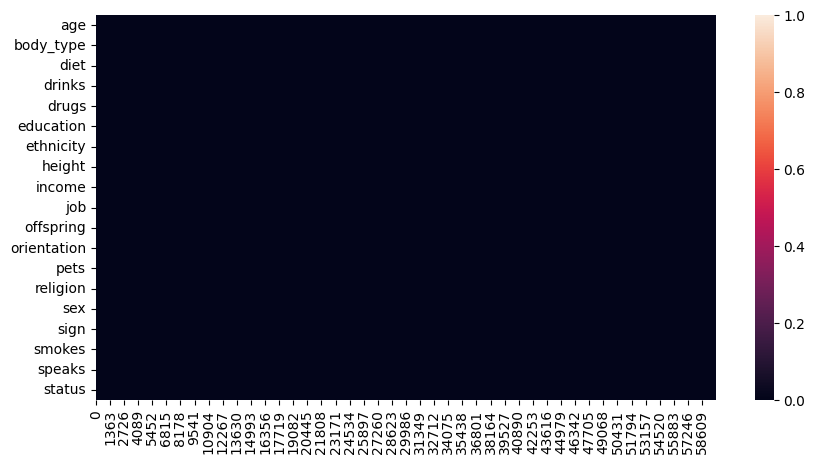

In [103]:
sns.heatmap(profiles.isnull().T.astype(int))

Now I'll do some encoding of the columns.

**education** should use ordinal encoding — ordered by level of academic achievement:
dropped out of high school → high school → two-year college → college/university → masters → law/med/ph.d

The same ordinal logic applies to:
- **drinks**: not at all → rarely → socially → often → very often → desperately
- **drugs**: never → sometimes → often
- **smokes**: no → trying to quit → when drinking → sometimes → yes

**pets** will be split using one-hot encoding into 6 binary columns:
has_dogs, has_cats, likes_dogs, likes_cats, dislikes_dogs, dislikes_cats.
The "have no opinion on pets" fill value will result in all-zero rows.

**sign** will be split into two separate columns:
1. The actual zodiac sign (label encoded) — extracted from the string
2. An ordinal "sign importance" score:
   - 0 → no sign listed / "it doesn't matter"
   - 1 → sign present, no opinion stated
   - 2 → "but it's important"
   - 3 → "and it's important"

**religion** will be split the same way as sign:
1. The religion/belief type (label encoded) — e.g. agnosticism, christianity, atheism...
2. An ordinal "seriousness" score:
   - 0 → not too serious about it
   - 1 → no modifier stated
   - 2 → very serious about it

**diet** will also be split into two columns:
1. Diet type (label encoded) — e.g. anything, vegetarian, vegan, kosher, halal, other
2. Strictness ordinal: mostly → [no modifier] → strictly

**ethnicity** will be multi-hot encoded — since users can select multiple ethnicities,
each base ethnicity (white, asian, black, hispanic/latin, indian, middle eastern,
pacific islander, native american, other) becomes its own binary column.

The remaining columns — **sex**, **orientation**, **status**, **body_type**, and **job** —
will use standard label encoding.

In [104]:
from sklearn.preprocessing import LabelEncoder

profiles_enc = profiles.copy()

# ─── 1. EDUCATION — ordinal (0=no HS .. 12=graduated PhD/Law/Med) ────────────
EDUCATION_ORDER = {
    'dropped out of high school':          0,
    'working on high school':              1,
    'high school':                         2,
    'graduated from high school':          3,
    'dropped out of space camp':           4,
    'dropped out of two-year college':     4,
    'space camp':                          5,
    'two-year college':                    5,
    'working on space camp':               5,
    'working on two-year college':         5,
    'graduated from space camp':           6,
    'graduated from two-year college':     6,
    'dropped out of college/university':   7,
    'college/university':                  8,
    'working on college/university':       8,
    'graduated from college/university':   9,
    'dropped out of masters program':     10,
    'dropped out of law school':          10,
    'dropped out of med school':          10,
    'dropped out of ph.d program':        10,
    'masters program':                    11,
    'working on masters program':         11,
    'law school':                         11,
    'working on law school':              11,
    'med school':                         11,
    'working on med school':              11,
    'ph.d program':                       11,
    'working on ph.d program':            11,
    'graduated from masters program':     12,
    'graduated from law school':          12,
    'graduated from med school':          12,
    'graduated from ph.d program':        12,
}
profiles_enc['education_ord'] = profiles_enc['education'].map(EDUCATION_ORDER)

# ─── 2. DRINKS — ordinal (0=not at all .. 5=desperately) ────────────────────
DRINKS_ORDER = {
    'not at all': 0, 'rarely': 1, 'socially': 2,
    'often': 3, 'very often': 4, 'desperately': 5
}
profiles_enc['drinks_ord'] = profiles_enc['drinks'].map(DRINKS_ORDER)

# ─── 3. DRUGS — ordinal (0=never .. 2=often) ─────────────────────────────────
DRUGS_ORDER = {'never': 0, 'sometimes': 1, 'often': 2}
profiles_enc['drugs_ord'] = profiles_enc['drugs'].map(DRUGS_ORDER)

# ─── 4. SMOKES — ordinal (0=no .. 4=yes) ─────────────────────────────────────
SMOKES_ORDER = {
    'no': 0, 'trying to quit': 1, 'when drinking': 2, 'sometimes': 3, 'yes': 4
}
profiles_enc['smokes_ord'] = profiles_enc['smokes'].map(SMOKES_ORDER)

# ─── 5. PETS — one-hot (6 binary columns) ────────────────────────────────────
# "have no opinion on pets" matches none of the patterns -> all zeros
pets = profiles_enc['pets']
profiles_enc['pets_has_dogs']      = pets.str.contains('has dogs',      na=False).astype(int)
profiles_enc['pets_has_cats']      = pets.str.contains('has cats',      na=False).astype(int)
profiles_enc['pets_likes_dogs']    = pets.str.contains('likes dogs',    na=False).astype(int)
profiles_enc['pets_likes_cats']    = pets.str.contains('likes cats',    na=False).astype(int)
profiles_enc['pets_dislikes_dogs'] = pets.str.contains('dislikes dogs', na=False).astype(int)
profiles_enc['pets_dislikes_cats'] = pets.str.contains('dislikes cats', na=False).astype(int)

# ─── 6. SIGN — zodiac label + importance ordinal ─────────────────────────────
# Importance: 0=doesn't matter, 1=neutral/mild, 2=matters a lot
ZODIAC_SIGNS = ['aquarius', 'aries', 'cancer', 'capricorn', 'gemini', 'leo',
                'libra', 'pisces', 'sagittarius', 'scorpio', 'taurus', 'virgo']

def parse_sign(val):
    v = val.replace('&rsquo;', "'").lower().strip()
    sign = 'unknown'
    for z in ZODIAC_SIGNS:
        if z in v:
            sign = z
            break
    if "doesn't matter" in v:
        importance = 0
    elif 'matters a lot' in v:
        importance = 2
    else:
        importance = 1   # plain sign or "fun to think about" -> neutral
    return sign, importance

sign_parsed              = profiles_enc['sign'].apply(parse_sign)
profiles_enc['sign_zodiac']     = sign_parsed.apply(lambda x: x[0])
profiles_enc['sign_importance'] = sign_parsed.apply(lambda x: x[1])
le_sign = LabelEncoder()
profiles_enc['sign_zodiac_enc'] = le_sign.fit_transform(profiles_enc['sign_zodiac'])

# ─── 7. RELIGION — type label + seriousness ordinal ──────────────────────────
# Seriousness: 0=laughing, 1=not too serious/neutral, 2=somewhat, 3=very serious
RELIGION_TYPES = ['agnosticism', 'atheism', 'buddhism', 'catholicism',
                  'christianity', 'hinduism', 'islam', 'judaism', 'other']

def parse_religion(val):
    v = val.replace('&rsquo;', "'").lower().strip()
    rel_type = 'other'
    for r in RELIGION_TYPES:
        if r in v:
            rel_type = r
            break
    if 'laughing about it' in v:
        seriousness = 0
    elif 'not too serious' in v:
        seriousness = 1
    elif 'somewhat serious' in v:
        seriousness = 2
    elif 'very serious' in v:
        seriousness = 3
    else:
        seriousness = 1   # no qualifier -> neutral
    return rel_type, seriousness

religion_parsed                      = profiles_enc['religion'].apply(parse_religion)
profiles_enc['religion_type']        = religion_parsed.apply(lambda x: x[0])
profiles_enc['religion_seriousness'] = religion_parsed.apply(lambda x: x[1])
le_religion = LabelEncoder()
profiles_enc['religion_type_enc']    = le_religion.fit_transform(profiles_enc['religion_type'])

# ─── 8. DIET — type label + strictness ordinal ───────────────────────────────
# Strictness: 1=mostly, 2=plain, 3=strictly
DIET_TYPES = ['halal', 'kosher', 'vegan', 'vegetarian', 'other', 'anything']

def parse_diet(val):
    v = val.lower().strip()
    if v.startswith('strictly '):
        strictness, v = 3, v[len('strictly '):]
    elif v.startswith('mostly '):
        strictness, v = 1, v[len('mostly '):]
    else:
        strictness = 2
    diet_type = 'anything'
    for d in DIET_TYPES:
        if d == v.strip():
            diet_type = d
            break
    return diet_type, strictness

diet_parsed                   = profiles_enc['diet'].apply(parse_diet)
profiles_enc['diet_type']       = diet_parsed.apply(lambda x: x[0])
profiles_enc['diet_strictness'] = diet_parsed.apply(lambda x: x[1])
le_diet = LabelEncoder()
profiles_enc['diet_type_enc']   = le_diet.fit_transform(profiles_enc['diet_type'])

# ─── 9. ETHNICITY — multi-hot (9 binary columns) ─────────────────────────────
ETHNICITY_MAP = {
    'white':             'eth_white',
    'asian':             'eth_asian',
    'black':             'eth_black',
    'hispanic / latin':  'eth_hispanic_latin',
    'indian':            'eth_indian',
    'middle eastern':    'eth_middle_eastern',
    'pacific islander':  'eth_pacific_islander',
    'native american':   'eth_native_american',
    'other':             'eth_other',
}
for eth, col in ETHNICITY_MAP.items():
    profiles_enc[col] = profiles_enc['ethnicity'].str.contains(eth, na=False).astype(int)

# ─── 10. REMAINING COLUMNS — label encoding ──────────────────────────────────
for col in ['sex', 'orientation', 'status', 'body_type', 'job']:
    le = LabelEncoder()
    profiles_enc[f'{col}_enc'] = le.fit_transform(profiles_enc[col])

# ─── Summary ─────────────────────────────────────────────────────────────────
new_cols = (
    ['education_ord', 'drinks_ord', 'drugs_ord', 'smokes_ord']
    + ['pets_has_dogs', 'pets_has_cats', 'pets_likes_dogs', 'pets_likes_cats',
       'pets_dislikes_dogs', 'pets_dislikes_cats']
    + ['sign_zodiac', 'sign_zodiac_enc', 'sign_importance']
    + ['religion_type', 'religion_type_enc', 'religion_seriousness']
    + ['diet_type', 'diet_type_enc', 'diet_strictness']
    + list(ETHNICITY_MAP.values())
    + ['sex_enc', 'orientation_enc', 'status_enc', 'body_type_enc', 'job_enc']
)
print(f"profiles_enc: {profiles.shape[1]} original + {len(new_cols)} encoded = {profiles_enc.shape[1]} total columns")
profiles_enc[new_cols].head()

profiles_enc: 19 original + 33 encoded = 52 total columns


,education_ord,drinks_ord,drugs_ord,smokes_ord,pets_has_dogs,pets_has_cats,pets_likes_dogs,pets_likes_cats,pets_dislikes_dogs,pets_dislikes_cats,...,eth_indian,eth_middle_eastern,eth_pacific_islander,eth_native_american,eth_other,sex_enc,orientation_enc,status_enc,body_type_enc,job_enc
0,8,2,0,3,0,0,1,1,0,0,...,0,0,0,0,0,1,2,3,0,19
1,5,3,1,0,0,0,1,1,0,0,...,0,0,0,0,0,1,2,3,2,8
2,12,2,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,2,0,10,14
3,8,2,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,2,3,10,18
4,9,2,0,0,0,0,1,1,0,0,...,0,0,0,0,1,1,2,3,1,0


Treating the essays as a "soup of words" and find the most common words, 2-word combinations (bigrams) and 3-word combinations (trigrams):

In [105]:
import re
from collections import Counter

# ── 1. Shared tokenisation (per-person) ──────────────────────────────────────
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','ma','im','ive','id','its','also','get','things','one'
}

def tokenize_essay(text):
    t = re.sub(r'<[^>]+>', ' ', str(text))
    t = re.sub(r'&[a-z]+;', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t.lower())
    return [w for w in t.split() if w not in STOPWORDS and len(w) > 1]

# essay_words: one list of tokens per person — reused by the visualisation cell
essay_words = (
    essays.fillna('')
          .apply(lambda row: ' '.join(row), axis=1)
          .apply(tokenize_essay)
)

# ── 2. Flatten into a single token list for n-gram analysis ──────────────────
filtered = [w for word_list in essay_words for w in word_list]

# ── 3. Frequency counts ───────────────────────────────────────────────────────
word_counts   = Counter(filtered)

bigram_counts  = Counter(
    (filtered[i], filtered[i+1])
    for i in range(len(filtered) - 1)
)

trigram_counts = Counter(
    (filtered[i], filtered[i+1], filtered[i+2])
    for i in range(len(filtered) - 2)
)

# ── 4. Top lists ──────────────────────────────────────────────────────────────
top_n = 30

top_words    = word_counts.most_common(top_n)
top_bigrams  = bigram_counts.most_common(top_n)
top_trigrams = trigram_counts.most_common(top_n)

print(f"=== Top {top_n} single words ===")
for word, count in top_words:
    print(f"  {word:<20} {count:>8,}")

print(f"\n=== Top {top_n} bigrams (2-word combinations) ===")
for (w1, w2), count in top_bigrams:
    print(f"  {w1+' '+w2:<30} {count:>8,}")

print(f"\n=== Top {top_n} trigrams (3-word combinations) ===")
for (w1, w2, w3), count in top_trigrams:
    print(f"  {w1+' '+w2+' '+w3:<40} {count:>8,}")

=== Top 30 single words ===
  like                  136,307
  love                  120,725
  good                   89,887
  music                  84,344
  friends                84,172
  people                 79,698
  life                   73,778
  time                   71,945
  food                   63,964
  new                    58,701
  really                 54,793
  movies                 49,089
  know                   45,954
  work                   45,451
  want                   44,693
  books                  40,892
  family                 40,431
  think                  39,965
  going                  38,198
  anything               38,177
  enjoy                  37,571
  much                   37,525
  go                     37,127
  fun                    34,633
  would                  34,071
  make                   33,972
  lot                    31,923
  working                30,586
  looking                29,735
  always                 29,305

=== Top 30 

Great! Now the data is clean and encoded, so we can make some preliminary visualizations and then form hypotheses.

**One data-quality issue first — income outliers.** The `income` field was a discrete dropdown, and a few high buckets sit far above the bulk of the data. Applying the standard IQR rule to the *disclosed* incomes (Q1 = \$20k, Q3 = \$100k → upper fence = Q3 + 1.5·IQR = **\$220k**) flags three outlier groups:

| income bucket | count |
|---|---|
| \$250,000 | 149 |
| \$500,000 | 48 |
| \$1,000,000 | 521 |

The \$1,000,000 group is the most suspicious of all: 521 people — more than the \$250k and \$500k buckets *combined* — piled up on the form's **maximum** value, which breaks the otherwise smooth decline from \$100k downward. On a dating site these are almost certainly aspirational / joke answers rather than real income (the mean disclosed income, \$104k, is more than double the \$50k median because of them).

We therefore drop all three flagged groups (718 rows) from the income analysis by setting their `income` to `NaN`, while keeping the rest of each profile intact. The `-1` "rather not say" values are likewise excluded from income plots.

In [106]:
# ─── Income outlier removal (IQR rule) ───────────────────────────────────────
# Compute the upper fence from the RAW disclosed incomes so the threshold is
# stable no matter how many times this cell is re-run.
disclosed = profiles.loc[profiles['income'] > 0, 'income']
q1, q3 = disclosed.quantile(0.25), disclosed.quantile(0.75)
income_fence = q3 + 1.5 * (q3 - q1)          # Q3 + 1.5*IQR  ->  $220,000

# The $250k / $500k / $1M buckets sit above the fence; the $1M bucket in
# particular is a pile-up artifact (521 people on the form's maximum value).
# Drop all three groups from the income analysis by setting them to NaN —
# the rest of each profile stays intact.
n_out = int((profiles_enc['income'] > income_fence).sum())
profiles_enc.loc[profiles_enc['income'] > income_fence, 'income'] = np.nan

print(f"Upper fence (Q3 + 1.5*IQR) = ${income_fence:,.0f}")
print(f"Removed {n_out} income outliers (set to NaN).")
print(f"Disclosed incomes remaining: {int((profiles_enc['income'] > 0).sum())}")
print("\nIncome buckets after removal:")
print(profiles_enc.loc[profiles_enc['income'] > 0, 'income'].value_counts().sort_index())

Upper fence (Q3 + 1.5*IQR) = $220,000
Removed 718 income outliers (set to NaN).
Disclosed incomes remaining: 10786

Income buckets after removal:
income
20000.0     2952
30000.0     1048
40000.0     1005
50000.0      975
60000.0      736
70000.0      707
80000.0     1111
100000.0    1621
150000.0     631
Name: count, dtype: int64


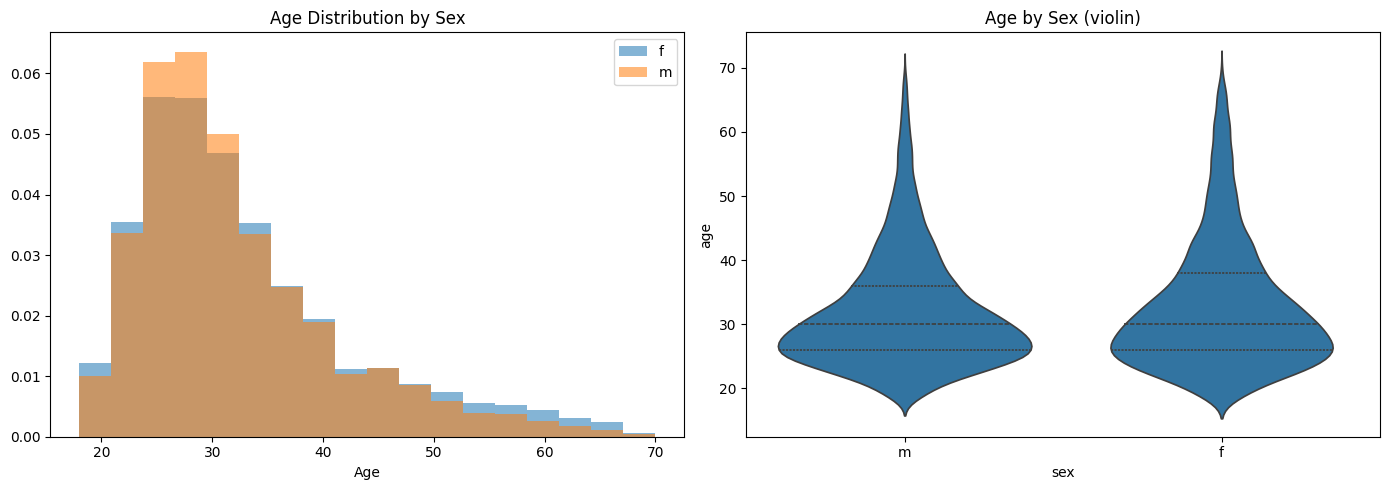

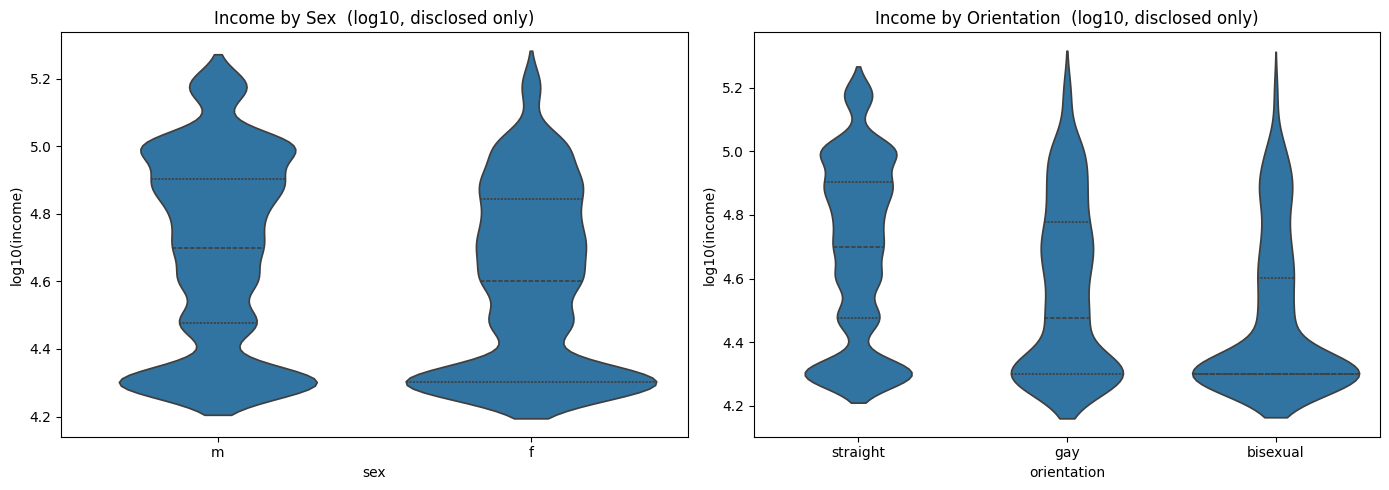

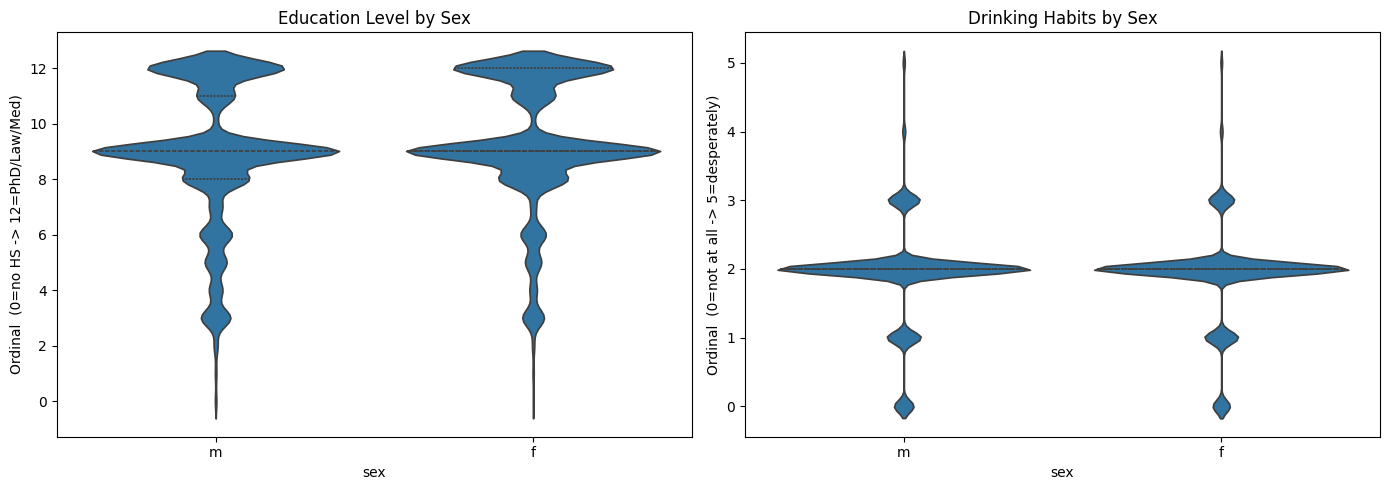

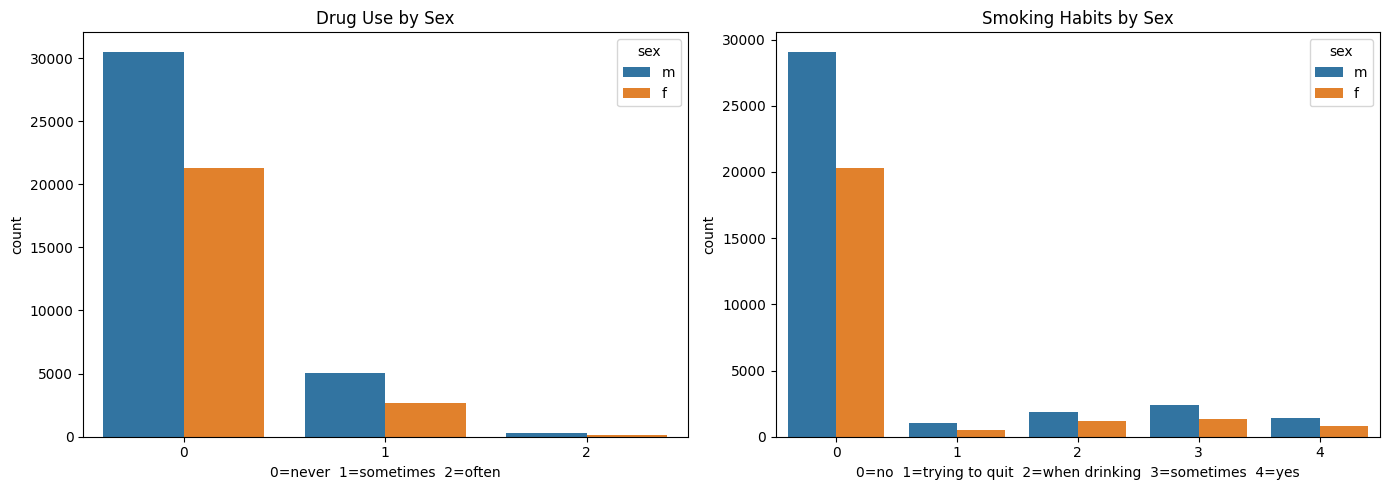

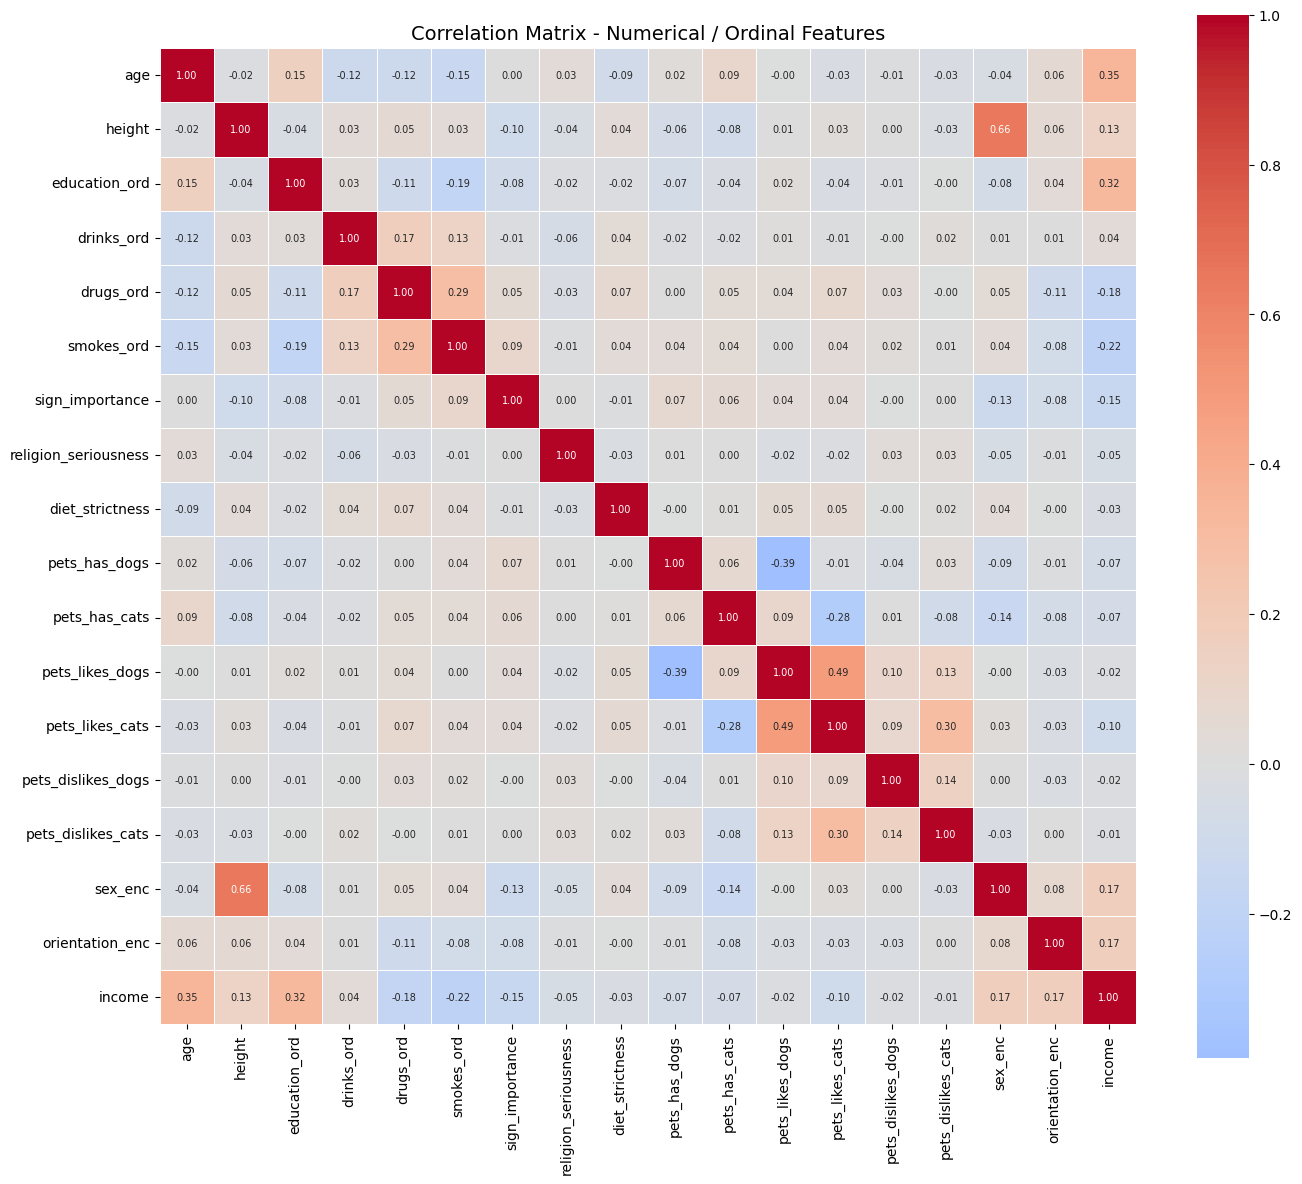

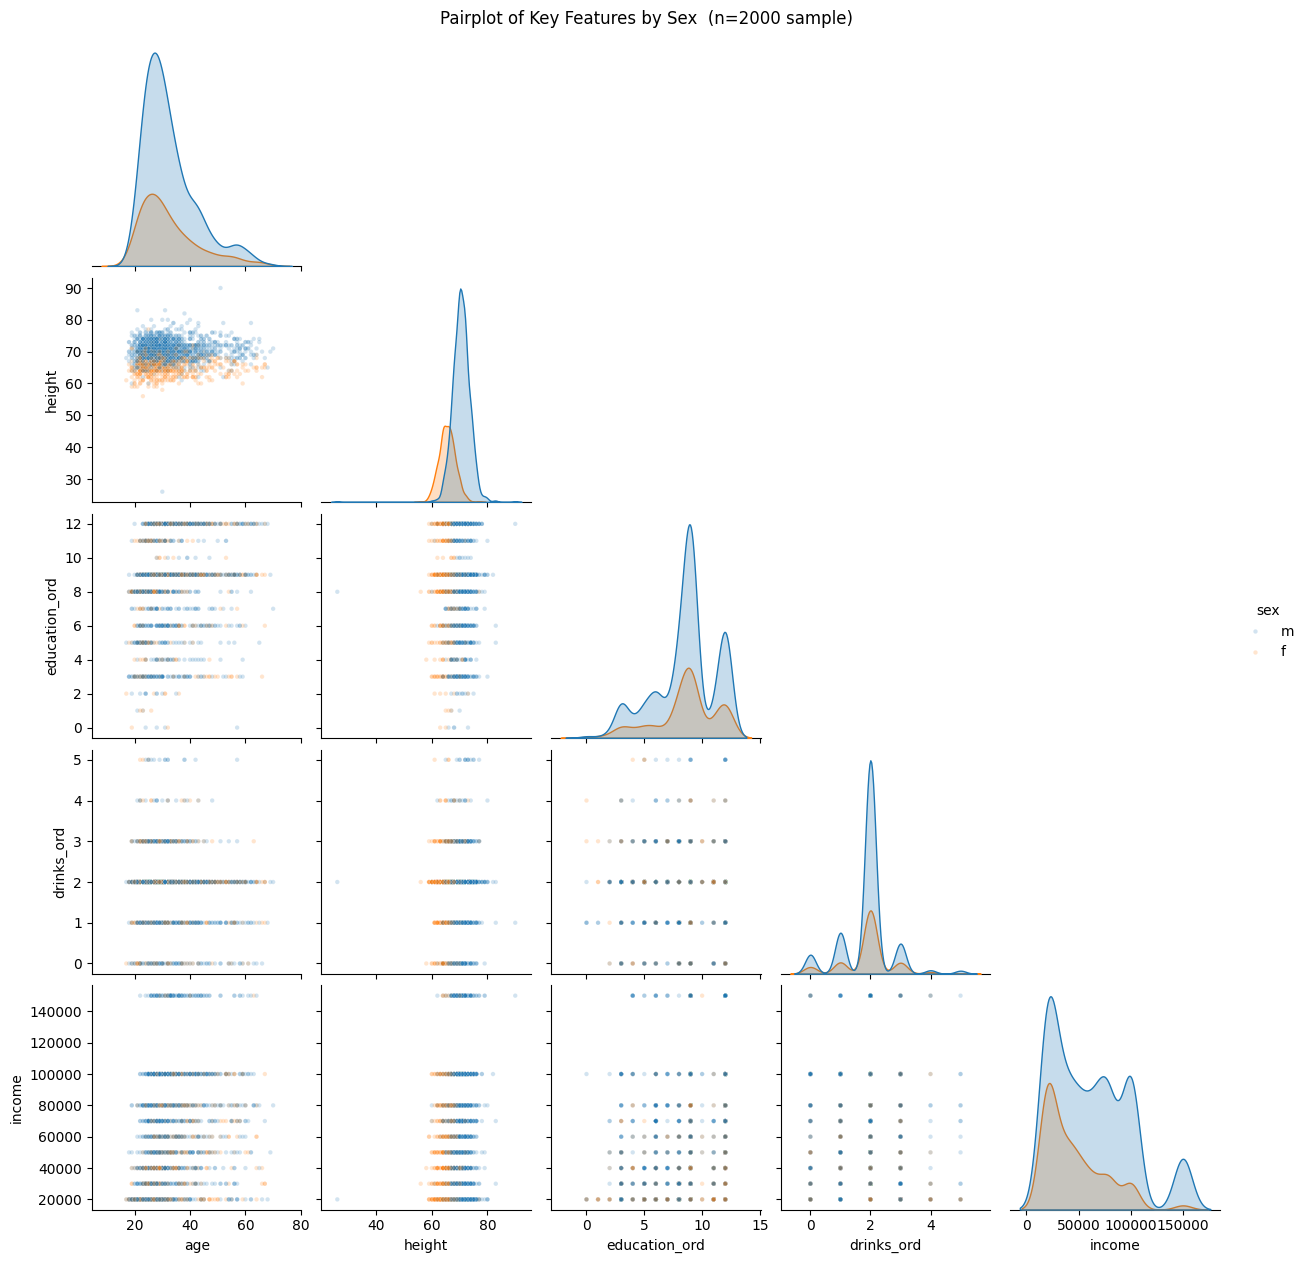

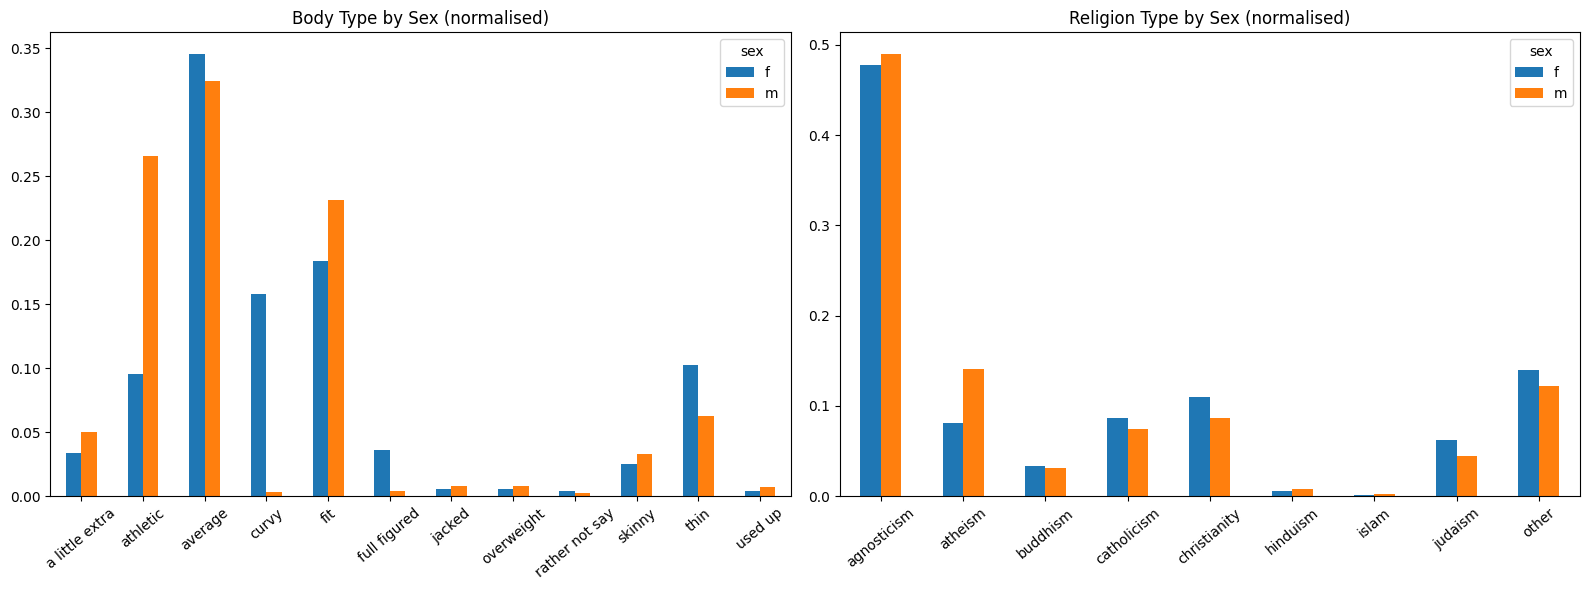

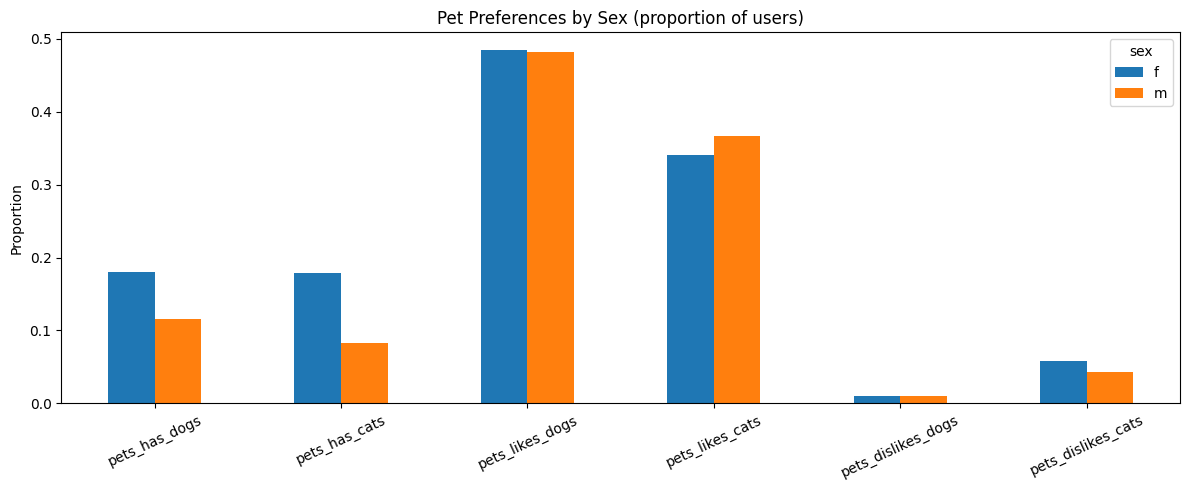

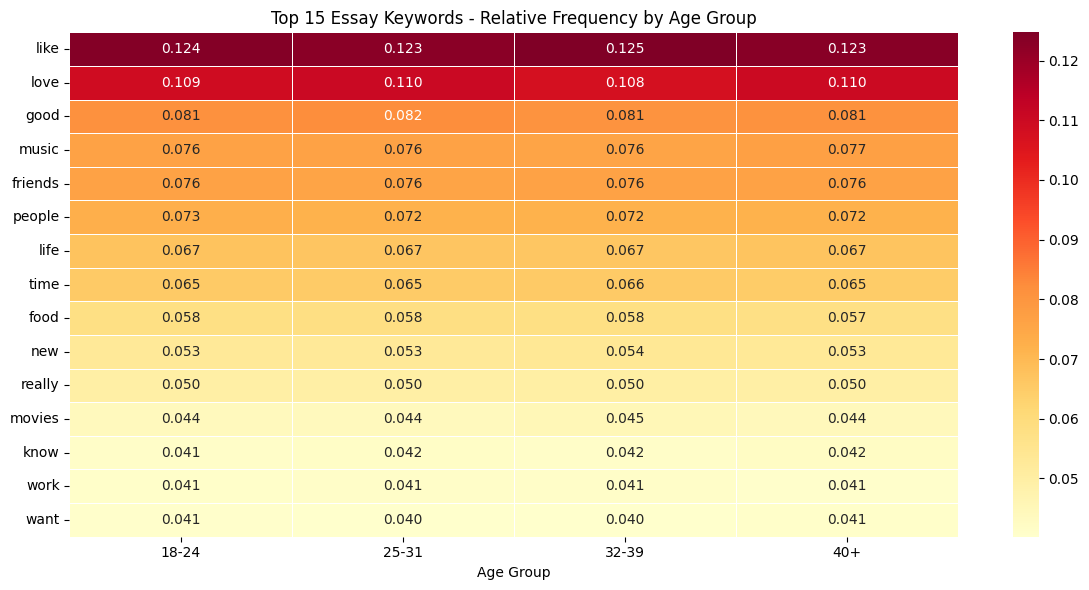

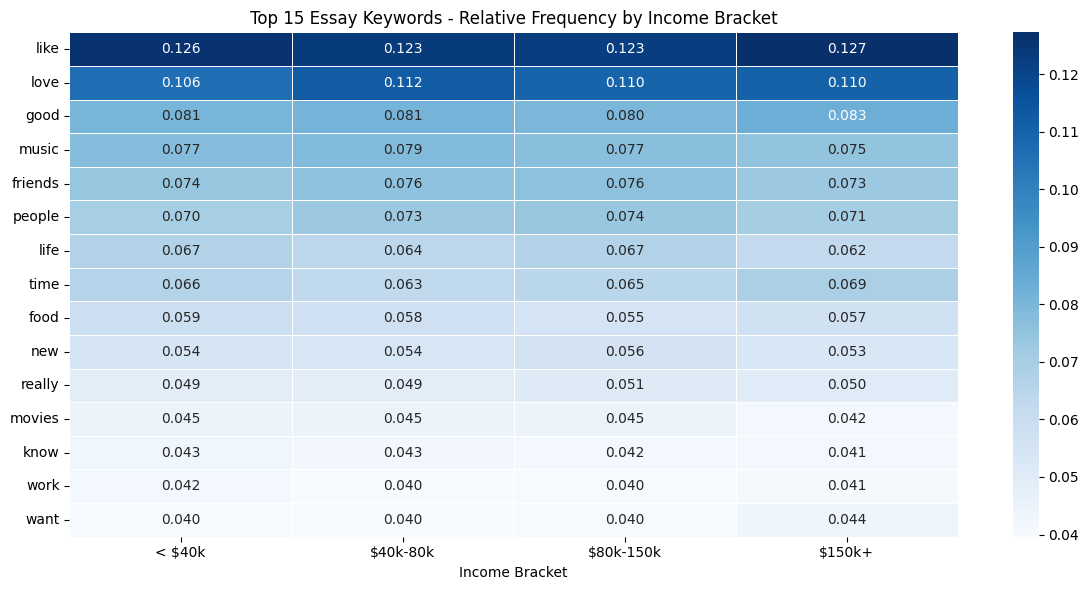

In [107]:
from collections import Counter   # essay_words and STOPWORDS defined in the soup cell above

# ─── 1. Age distribution by sex ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_df = profiles_enc[profiles_enc['age'].between(18, 70)]

for sex in sorted(profiles_enc['sex'].unique()):
    axes[0].hist(age_df[age_df['sex'] == sex]['age'], bins=18,
                 alpha=0.55, label=sex, density=True)
axes[0].set_title('Age Distribution by Sex')
axes[0].set_xlabel('Age')
axes[0].legend()

sns.violinplot(data=age_df, x='sex', y='age', inner='quartile', ax=axes[1])
axes[1].set_title('Age by Sex (violin)')
plt.tight_layout()
plt.show()

# ─── 2. Income by sex and orientation (log scale, disclosed only) ─────────────
income_df = profiles_enc[profiles_enc['income'] > 0].copy()
income_df['log_income'] = np.log10(income_df['income'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=income_df, x='sex', y='log_income', inner='quartile', ax=axes[0])
axes[0].set_title('Income by Sex  (log10, disclosed only)')
axes[0].set_ylabel('log10(income)')

sns.violinplot(data=income_df, x='orientation', y='log_income', inner='quartile', ax=axes[1])
axes[1].set_title('Income by Orientation  (log10, disclosed only)')
axes[1].set_ylabel('log10(income)')
plt.tight_layout()
plt.show()

# ─── 3. Education and drinking by sex ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=profiles_enc, x='sex', y='education_ord', inner='quartile', ax=axes[0])
axes[0].set_title('Education Level by Sex')
axes[0].set_ylabel('Ordinal  (0=no HS -> 12=PhD/Law/Med)')

sns.violinplot(data=profiles_enc, x='sex', y='drinks_ord', inner='quartile', ax=axes[1])
axes[1].set_title('Drinking Habits by Sex')
axes[1].set_ylabel('Ordinal  (0=not at all -> 5=desperately)')
plt.tight_layout()
plt.show()

# ─── 4. Drugs and smoking by sex ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=profiles_enc, x='drugs_ord', hue='sex', ax=axes[0])
axes[0].set_title('Drug Use by Sex')
axes[0].set_xlabel('0=never  1=sometimes  2=often')

sns.countplot(data=profiles_enc, x='smokes_ord', hue='sex', ax=axes[1])
axes[1].set_title('Smoking Habits by Sex')
axes[1].set_xlabel('0=no  1=trying to quit  2=when drinking  3=sometimes  4=yes')
plt.tight_layout()
plt.show()

# ─── 5. Correlation matrix ───────────────────────────────────────────────────
corr_cols = ['age', 'height', 'education_ord', 'drinks_ord', 'drugs_ord',
             'smokes_ord', 'sign_importance', 'religion_seriousness',
             'diet_strictness', 'pets_has_dogs', 'pets_has_cats',
             'pets_likes_dogs', 'pets_likes_cats',
             'pets_dislikes_dogs', 'pets_dislikes_cats',
             'sex_enc', 'orientation_enc']
corr_df = profiles_enc[corr_cols].copy()
corr_df['income'] = profiles_enc['income'].replace(-1, np.nan)

plt.figure(figsize=(14, 12))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, annot_kws={'size': 7})
plt.title('Correlation Matrix - Numerical / Ordinal Features', fontsize=14)
plt.tight_layout()
plt.show()

# ─── 6. Pairplot of key features by sex (sampled for speed) ──────────────────
pp_df = profiles_enc[['age', 'height', 'education_ord', 'drinks_ord', 'sex']].copy()
pp_df['income'] = profiles_enc['income'].replace(-1, np.nan)
sns.pairplot(pp_df.dropna().sample(2000, random_state=42), hue='sex',
             plot_kws={'alpha': 0.2, 's': 10}, diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Key Features by Sex  (n=2000 sample)', y=1.01)
plt.show()

# ─── 7. Body type and Religion distributions by sex ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bt = profiles_enc.groupby(['sex', 'body_type']).size().unstack(fill_value=0)
bt.div(bt.sum(axis=1), axis=0).T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Body Type by Sex (normalised)')
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xlabel('')

rel = profiles_enc.groupby(['sex', 'religion_type']).size().unstack(fill_value=0)
rel.div(rel.sum(axis=1), axis=0).T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Religion Type by Sex (normalised)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

# ─── 8. Pet preferences by sex ───────────────────────────────────────────────
pet_cols = ['pets_has_dogs', 'pets_has_cats', 'pets_likes_dogs',
            'pets_likes_cats', 'pets_dislikes_dogs', 'pets_dislikes_cats']
profiles_enc.groupby('sex')[pet_cols].mean().T.plot(kind='bar', figsize=(12, 5))
plt.title('Pet Preferences by Sex (proportion of users)')
plt.ylabel('Proportion')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# ─── 9. Top keywords by age group ────────────────────────────────────────────
age_bins_g   = [17, 24, 31, 39, 100]
age_labels_g = ['18-24', '25-31', '32-39', '40+']
profiles_enc['age_group'] = pd.cut(profiles_enc['age'],
                                   bins=age_bins_g, labels=age_labels_g)

age_word_counts = {}
for grp in age_labels_g:
    mask = profiles_enc['age_group'] == grp
    words = [w for wlist in essay_words[mask] for w in wlist]
    age_word_counts[grp] = Counter(words)

top15_age = [w for w, _ in sum(age_word_counts.values(), Counter()).most_common(15)]
freq_age = pd.DataFrame(
    {g: {w: age_word_counts[g].get(w, 0) for w in top15_age} for g in age_labels_g}
)
freq_age = freq_age.div(freq_age.sum())

plt.figure(figsize=(12, 6))
sns.heatmap(freq_age, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Top 15 Essay Keywords - Relative Frequency by Age Group')
plt.xlabel('Age Group')
plt.tight_layout()
plt.show()

# ─── 10. Top keywords by income bracket ──────────────────────────────────────
income_brackets = {
    '< $40k':    profiles_enc['income'].between(1, 39999),
    '$40k-80k':  profiles_enc['income'].between(40000, 79999),
    '$80k-150k': profiles_enc['income'].between(80000, 149999),
    '$150k+':    profiles_enc['income'] >= 150000,
}
inc_word_counts = {}
for lbl, mask in income_brackets.items():
    words = [w for wlist in essay_words[mask] for w in wlist]
    inc_word_counts[lbl] = Counter(words)

top15_inc = [w for w, _ in sum(inc_word_counts.values(), Counter()).most_common(15)]
freq_inc = pd.DataFrame(
    {l: {w: inc_word_counts[l].get(w, 0) for w in top15_inc} for l in income_brackets}
)
freq_inc = freq_inc.div(freq_inc.sum())

plt.figure(figsize=(12, 6))
sns.heatmap(freq_inc, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5)
plt.title('Top 15 Essay Keywords - Relative Frequency by Income Bracket')
plt.xlabel('Income Bracket')
plt.tight_layout()
plt.show()